<a href="https://colab.research.google.com/github/maheshmaila793-byte/EDA-Business_Intelligence/blob/main/SkillCraft_Task_03_Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully!

[Step 1] Downloading Bank Marketing dataset...
Dataset loaded successfully!
Dataset Shape: (4521, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no



[Step 2] Checking dataset information:
Missing values per column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Target variable ('y') distribution:
y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

[Step 3] Preprocessing and encoding features...
Encoded feature space shape: (4521, 42)
Training samples: 3616 | Testing samples: 905

[Step 5] Decision Tree Model Trained Successfully!

========== MODEL PERFORMANCE ==========
Accuracy : 88.62%
Precision: 50.82%
Recall   : 29.81%
F1-Score : 0.3758

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94       801
           1       0.51      0.30      0.38       104

    accuracy                           0.89       905
   macro avg   

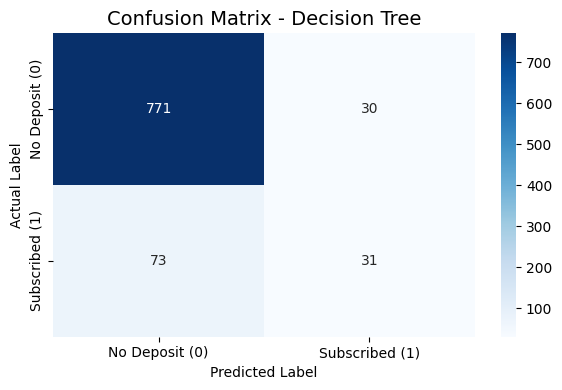

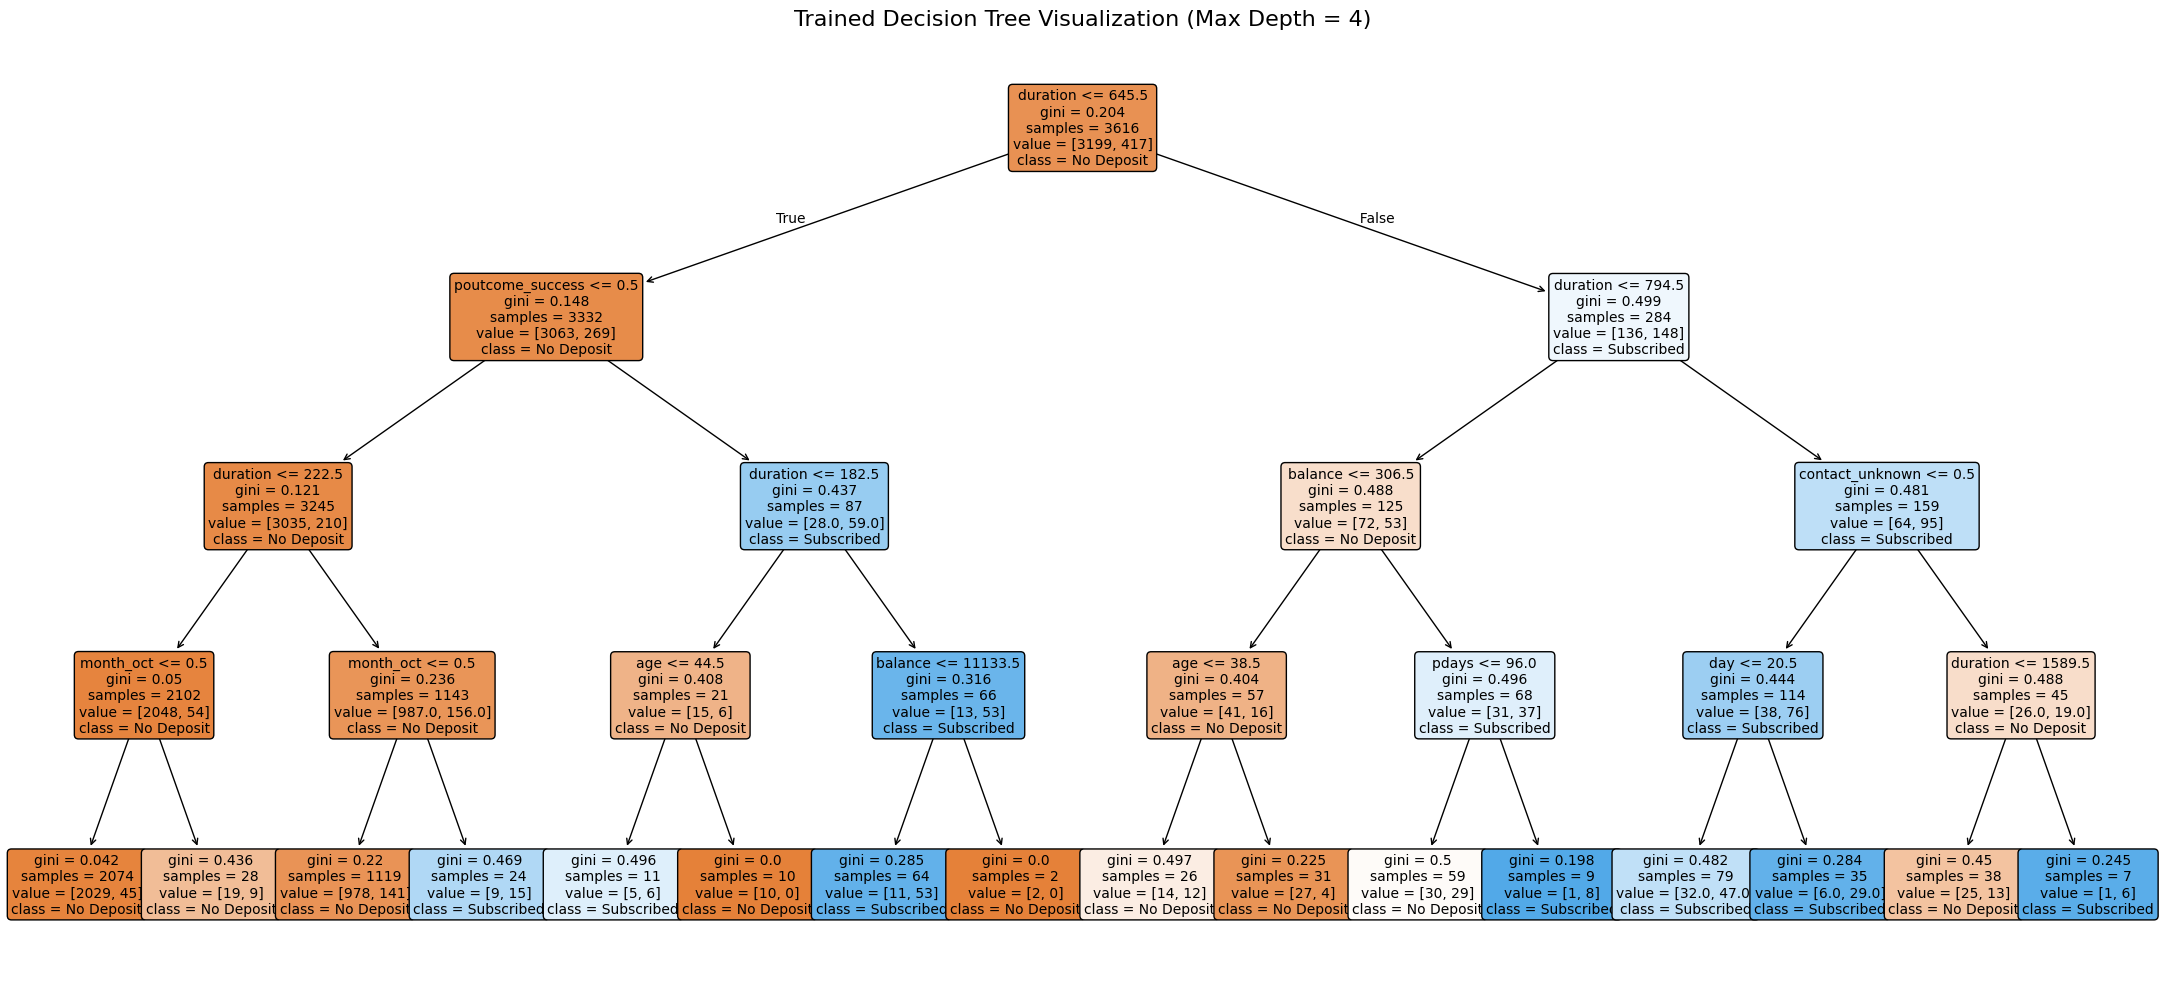

/tmp/ipykernel_1444/2294978857.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")


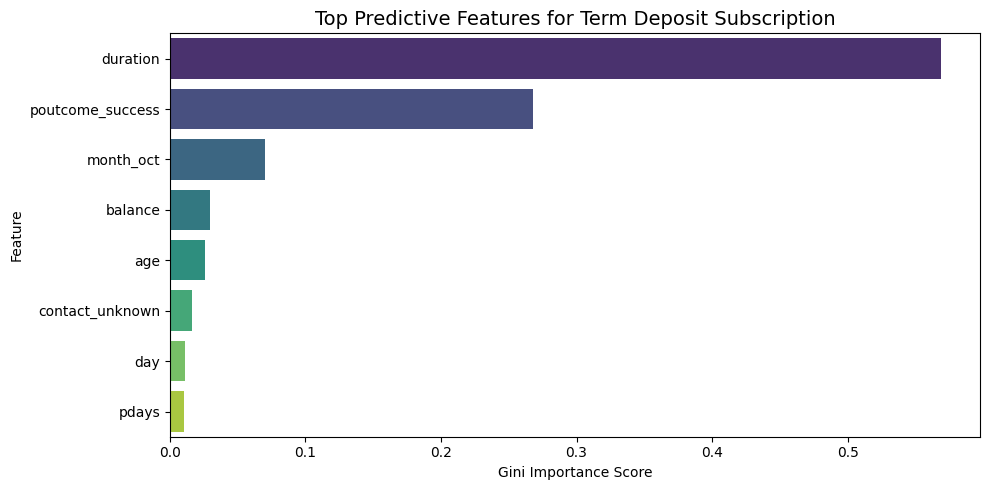


========== TOP 5 FEATURES ==========


,Feature,Importance
3,duration,0.569176
40,poutcome_success,0.267744
37,month_oct,0.069969
1,balance,0.029236
0,age,0.026215



TASK 03 COMPLETED SUCCESSFULLY!


In [1]:
# ============================================================
# SKILLCRAFT TECHNOLOGY - TASK 03
# Decision Tree Classifier - Bank Marketing Dataset
# ============================================================

import io
import urllib.request
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("Libraries imported successfully!")

# ------------------------------------------------------------
# 1. Download & Extract Dataset from UCI Repository
# ------------------------------------------------------------
print("\n[Step 1] Downloading Bank Marketing dataset...")
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
response = urllib.request.urlopen(req)
main_zip = zipfile.ZipFile(io.BytesIO(response.read()))

# Extract inner zip (bank.zip is clean, fast, and contains ~4,521 rows)
with main_zip.open("bank.zip") as z:
    inner_zip = zipfile.ZipFile(io.BytesIO(z.read()))
    with inner_zip.open("bank.csv") as f:
        # The UCI Bank dataset uses ';' as a delimiter
        df = pd.read_csv(f, sep=";")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# ------------------------------------------------------------
# 2. Check Missing Values & Structure
# ------------------------------------------------------------
print("\n[Step 2] Checking dataset information:")
print("Missing values per column:\n", df.isnull().sum())
print("\nTarget variable ('y') distribution:")
print(df["y"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 3. Data Preprocessing & Encoding
# ------------------------------------------------------------
print("\n[Step 3] Preprocessing and encoding features...")

# Convert target column: 'yes' -> 1, 'no' -> 0
df["y"] = df["y"].map({"yes": 1, "no": 0})

# Separate features (X) and target (y)
X = df.drop("y", axis=1)
y = df["y"]

# One-Hot Encode categorical columns
X = pd.get_dummies(X, drop_first=True)
print(f"Encoded feature space shape: {X.shape}")

# ------------------------------------------------------------
# 4. Train-Test Split (80% Train, 20% Test)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

# ------------------------------------------------------------
# 5. Train Decision Tree Classifier
# ------------------------------------------------------------
# Using max_depth=4 to prevent overfitting and keep the tree interpretable
clf = DecisionTreeClassifier(
    criterion="gini", max_depth=4, min_samples_split=20, random_state=42
)
clf.fit(X_train, y_train)
print("\n[Step 5] Decision Tree Model Trained Successfully!")

# ------------------------------------------------------------
# 6. Model Evaluation
# ------------------------------------------------------------
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall   : {rec * 100:.2f}%")
print(f"F1-Score : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 7. Confusion Matrix Plot
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Deposit (0)", "Subscribed (1)"],
    yticklabels=["No Deposit (0)", "Subscribed (1)"],
)
plt.title("Confusion Matrix - Decision Tree", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Decision Tree Visualization
# ------------------------------------------------------------
plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["No Deposit", "Subscribed"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Trained Decision Tree Visualization (Max Depth = 4)", fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Feature Importance Analysis
# ------------------------------------------------------------
importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": clf.feature_importances_}
).sort_values(by="Importance", ascending=False)

# Filter top 10 most influential features
top_features = importance_df[importance_df["Importance"] > 0].head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")
plt.title("Top Predictive Features for Term Deposit Subscription", fontsize=14)
plt.xlabel("Gini Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\n========== TOP 5 FEATURES ==========")
display(top_features.head(5))
print("\nTASK 03 COMPLETED SUCCESSFULLY!")
